# torchdeform — a hands-on guide
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/robertpop99/torchdeform/blob/main/examples/guide.ipynb)

*A practical walkthrough.*

This notebook is a companion to `tutorial.ipynb`. The tutorial is a fast **visual
tour**; this one goes slower and explains **why** each step exists, in the
language of ground deformation and InSAR rather than the language of tensors.

By the end you will be able to:

1. Build a synthetic surface-deformation signal from a physical source (a magma
   chamber, a fault, a dyke) and see what a satellite would measure.
2. Add realistic atmospheric noise.
3. Assemble a full synthetic interferogram, and generate **thousands** of them as
   a dataset for training a machine-learning model.
4. Write your **own prior** — a statement of "what parameter values are plausible
   for my volcano / my fault" — and plug it straight into the generator.
5. Run a small **inversion**: given an interferogram, recover the source
   parameters by gradient descent. Here the forward model is *differentiable*, so
   gradients come for free.


## 0. Setup

We import the library and define two small plotting helpers so that later cells
stay short. You can safely skip reading the helper code — for short:

- `field(t)` turns a result into a plain 2-D image we can plot.
- `imshow(...)` draws that image with sensible colours (red/blue for
  displacement, a cyclic colour-wheel for *wrapped* phase).

Everything is computed on a fixed **observation grid**: a 128×128 raster of
ground points, 200 m apart, so the scene is about 25 km across.

In [1]:
%matplotlib inline
import math
import torch
import numpy as np
import matplotlib.pyplot as plt

import torchdeform
from torchdeform import (MogiSource, PennySource, PCDMSource, OkadaSourceSimple,
                         okada_params_from_fault, los_vector)
from torchdeform.observation.insar import to_phase, wrap_phase, phase_to_los
from torchdeform.atmosphere import turbulent_aps, stratified_aps, orbital_ramp
from torchdeform.simulation import (
    ObservationGrid, SourceGenerator, DeformationGenerator, GeometryGenerator,
    AtmosphereGenerator, InterferogramGenerator, InsarDataset, synthetic_dem, DEMPatchSampler,
    UniformPrior, DEFAULT_MOGI_PRIOR, DEFAULT_EARTHQUAKE_PRIOR,
    DEFAULT_PENNY_PRIOR, DEFAULT_PCDM_PRIOR, DEFAULT_S1_GEOMETRY_PRIOR,
)
from torchdeform.simulation.priors import (
    Prior, MogiPrior, LogUniformPrior, SignedLogUniformPrior, MultimodalPrior,
)

torch.manual_seed(0)
plt.rcParams["figure.dpi"] = 70          # keep the committed notebook lightweight
print("torchdeform", torchdeform.__version__)

torchdeform 0.1.0


In [2]:
# --- the observation grid: a 128 x 128 patch of ground, 200 m per pixel ---
ROWS = COLS = 128
PS = 200.0                                   # metres per pixel
grid = ObservationGrid(ROWS, COLS, psizex=PS, psizey=PS)
x_obs, y_obs = grid.coords(1)                # ground coordinates, one scene: shape [1, N]
z = torch.zeros(1)                           # source sits at the centre (x = y = 0)

# axis extent in km, and two small plotting helpers
EXT = [-(COLS - 1) * PS / 2e3, (COLS - 1) * PS / 2e3,
       -(ROWS - 1) * PS / 2e3, (ROWS - 1) * PS / 2e3]

def field(t):
    "Turn a model result into a 2-D image (numpy array) we can plot."
    return t.detach().reshape(ROWS, COLS).cpu().numpy()

def imshow(ax, img, title, cyclic=False, unit=""):
    "Draw an image: cyclic colour-wheel for wrapped phase, red/blue otherwise."
    if cyclic:
        m = ax.imshow(img, extent=EXT, origin="lower", cmap="twilight_shifted",
                      vmin=-math.pi, vmax=math.pi)
    else:
        v = float(np.abs(img).max()) or 1.0
        m = ax.imshow(img, extent=EXT, origin="lower", cmap="RdBu_r", vmin=-v, vmax=v)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("east (km)", fontsize=8); ax.set_ylabel("north (km)", fontsize=8)
    ax.tick_params(labelsize=7)
    cb = plt.colorbar(m, ax=ax, fraction=0.046, pad=0.04)
    if unit: cb.set_label(unit, fontsize=8)

## 1. Problem statement

An **interferogram** measures how much the ground moved between two satellite
passes, along the satellite's *line of sight*. Buried processes — a filling magma
chamber, slip on a fault, an inflating dyke — push the surface up, down, and
sideways. The satellite sees a projection of that motion, wrapped into
fringes, and buried under **atmospheric noise** that often looks similar
to deformation.

To train a machine-learning model to recognise these signals — or to test an
inversion method — you need **many labelled examples**: interferograms where you
know exactly what source produced them. Real labelled data is scarce. So we
*synthesise* it.

`torchdeform` builds this chain, step by step:

```
   source parameters        ground motion         satellite view      observable
  (depth, volume, ...)  ->   (east/north/up)  ->   (line of sight)  ->  (wrapped phase)
        physics                                       + atmosphere
```

Everything is written in PyTorch, which means the whole chain is
**differentiable** — a property we cash in during the inversion at the end. But
for the first part of this notebook, just think of it as a physics-based
image generator.

## 2. A deformation you can see: the Mogi source

The simplest useful source is the **Mogi model**: a point of volume change buried
in an elastic half-space — a good first approximation for an inflating or
deflating magma chamber. It has just two parameters:

- **depth** — how far below the surface (metres, positive down),
- **delta_v** — the volume change (cubic metres; positive = inflation).

Calling the model returns the ground displacement in three directions — **E**ast,
**N**orth, **U**p — at every point on our grid. For a Mogi source the pattern is a
symmetric bullseye: straight up over the source, and radially outward around it.

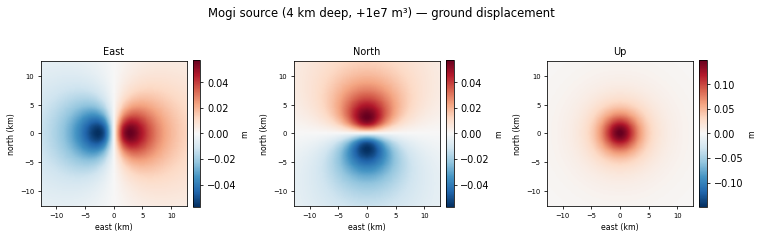

In [3]:
mogi = MogiSource()
disp = mogi(x_obs, y_obs,
            source_x=z, source_y=z,
            depth=torch.tensor([4000.0]),      # 4 km deep
            delta_v=torch.tensor([1e7]))       # +10 million m^3 (inflation)

fig, ax = plt.subplots(1, 3, figsize=(11, 3.2))
imshow(ax[0], field(disp.e), "East", unit="m")
imshow(ax[1], field(disp.n), "North", unit="m")
imshow(ax[2], field(disp.u), "Up", unit="m")
fig.suptitle("Mogi source (4 km deep, +1e7 m³) — ground displacement", y=1.04)
plt.tight_layout(); plt.show()

**The physics in one experiment.** A shallow source makes a tight, tall bump; a
deep source makes a broad, gentle one. This is exactly the intuition an inversion exploits: the *width*
of the signal tells you the *depth*.

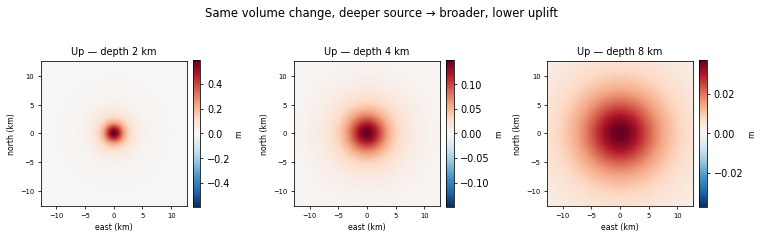

In [4]:
depths = [2000.0, 4000.0, 8000.0]
fig, ax = plt.subplots(1, 3, figsize=(11, 3.2))
for a, dep in zip(ax, depths):
    d = mogi(x_obs, y_obs, source_x=z, source_y=z,
             depth=torch.tensor([dep]), delta_v=torch.tensor([1e7]))
    imshow(a, field(d.u), f"Up — depth {dep/1000:.0f} km", unit="m")
fig.suptitle("Same volume change, deeper source → broader, lower uplift", y=1.04)
plt.tight_layout(); plt.show()

## 3. From ground motion to what the satellite sees

The satellite measures the projection
of the 3-D motion onto its **line of sight (LOS)** — the direction from the ground
to the spacecraft. That direction is set by the acquisition geometry, described by
two angles:

- **heading** — the azimuth the satellite flies along (degrees),
- **incidence** — the angle of the look direction away from vertical (degrees).

`los_vector(heading, incidence)` builds that unit vector; `disp.to_los(los)`
projects the displacement onto it. Positive LOS = motion *toward* the satellite.
(An optional `look_side` selects which side the radar looks: `+1` right-looking —
the Sentinel-1 default used here — or `-1` left-looking.)

Then two more steps turn displacement into an interferogram:

1. **Phase** is proportional to LOS displacement: `phase = -4π · d_los / λ`.
   It counts how many wavelengths of extra path the radar travelled.
2. **Wrapping**: the instrument only measures phase *modulo 2π*. So the smooth
   ramp of true phase gets folded into repeating **fringes**. Each colour cycle =
   half a wavelength of ground motion (~2.8 cm for Sentinel-1). Here we can
   generate *both* and use the clean one as a training label.

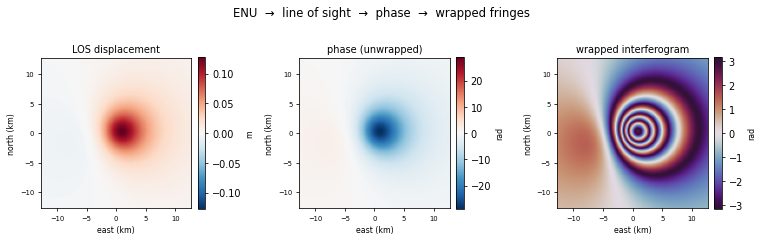

In [5]:
los = los_vector(torch.tensor([-13.0]), torch.tensor([39.0]))   # Sentinel-1-like geometry
d_los = disp.to_los(los)                                        # project ENU -> LOS
phase = to_phase(d_los)                                         # LOS metres -> radians
wrapped = wrap_phase(phase)                                     # fold into fringes

fig, ax = plt.subplots(1, 3, figsize=(11, 3.2))
imshow(ax[0], field(d_los), "LOS displacement", unit="m")
imshow(ax[1], field(phase), "phase (unwrapped)", unit="rad")
imshow(ax[2], field(wrapped), "wrapped interferogram", cyclic=True, unit="rad")
fig.suptitle("ENU  →  line of sight  →  phase  →  wrapped fringes", y=1.04)
plt.tight_layout(); plt.show()

## 4. The source zoo — which model for which process

Different geological processes call for different source models. `torchdeform`
provides the standard analytic ones. Here they are side by side, each shown the
way you'd actually observe it — projected to LOS and wrapped:

| Source | Models | Key parameters |
|---|---|---|
| **Mogi** | inflating/deflating magma point | depth, volume |
| **Okada** (earthquake) | slip on a rectangular fault | strike, dip, rake, slip, size |
| **Okada** (dyke) | a near-vertical opening crack | strike, dip≈90°, opening |
| **Okada** (sill) | a near-horizontal opening crack | dip≈0°, opening |
| **Penny crack** | a circular pressurised crack | depth, radius, pressure |
| **pCDM** | a general point volume source (any shape) | depth, 3 tilts, 3 volumes |

Don't worry about the exact parameter values below — the point is that *one
library* covers volcanoes and earthquakes with a consistent interface.

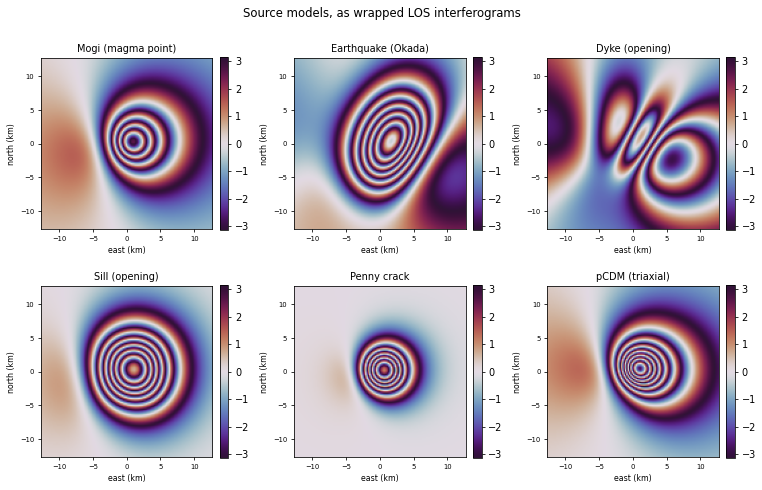

In [6]:
def wrapped_los(d):
    return field(wrap_phase(to_phase(d.to_los(los))))

def okada(strike, dip, rake, slip, opening, top_depth, length, width):
    p = {k: torch.tensor([v]) for k, v in dict(
        strike=strike, dip=dip, rake=rake, slip=slip, opening=opening,
        top_depth=top_depth, length=length, width=width).items()}
    return OkadaSourceSimple()(x_obs, y_obs, source_x=z, source_y=z,
                               **okada_params_from_fault(p))

panels = {
    "Mogi (magma point)":  disp,
    "Earthquake (Okada)":  okada(30, 45, 90, 1.0, 0.0, 5000, 9000, 6000),
    "Dyke (opening)":      okada(30, 85, 0.0, 0.0, 1.0, 3500, 8000, 5000),
    "Sill (opening)":      okada(0, 5, 0.0, 0.0, 0.6, 5000, 6000, 6000),
    "Penny crack":         PennySource()(x_obs, y_obs, source_x=z, source_y=z,
                               depth=torch.tensor([3000.0]),
                               radius=torch.tensor([2500.0]),
                               pressure=torch.tensor([5e6])),
    "pCDM (triaxial)":     PCDMSource()(x_obs, y_obs, source_x=z, source_y=z,
                               depth=torch.tensor([4000.0]),
                               omega_x=torch.tensor([0.3]), omega_y=torch.tensor([-0.2]),
                               omega_z=torch.tensor([0.5]),
                               dv_x=torch.tensor([6e6]), dv_y=torch.tensor([3e6]),
                               dv_z=torch.tensor([9e6])),
}
fig, axs = plt.subplots(2, 3, figsize=(11, 7))
for a, (name, d) in zip(axs.ravel(), panels.items()):
    imshow(a, wrapped_los(d), name, cyclic=True)
fig.suptitle("Source models, as wrapped LOS interferograms", y=1.0)
plt.tight_layout(); plt.show()

## 5. Why a "flat" interferogram isn't empty: atmosphere

If you took an interferogram over ground that didn't move, it would not be
blank. The radar signal passes through the atmosphere twice, and small changes in
water vapour and pressure between the two passes add a spurious **atmospheric
phase screen (APS)**. This is the dominant nuisance signal in real InSAR, and a
model that has never seen it will fail on real data.

`torchdeform` builds an APS from three physically-motivated pieces:

- **Orbital ramp** — a long-wavelength tilt across the scene from small orbit errors.
- **Stratified (topography-correlated)** — delay that tracks elevation, because the
  air column above a mountain differs from that above a valley. Needs a DEM.
- **Turbulent** — spatially-correlated random noise from water-vapour turbulence,
  with a realistic Kolmogorov power spectrum.

We take a DEM (here a real Copernicus GLO-30 tile) and each component, then add them up.

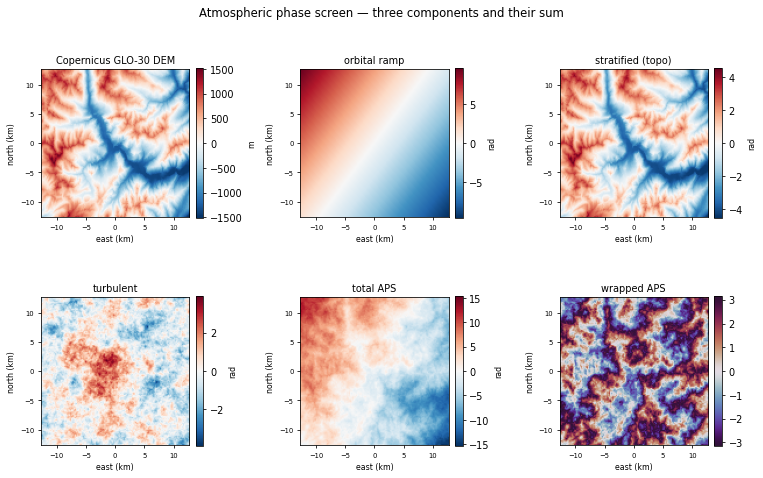

In [7]:
# Real Copernicus GLO-30 topography (French Alps) as the DEM, reused for the full
# pipeline below. from_copernicus fetches the tile into memory (needs network + the
# optional `rasterio` extra); for a zero-setup offline DEM swap in
# `synthetic_dem(1, ROWS, COLS, relief=800.0, psizex=PS, psizey=PS, generator=g)`.
dem_sampler = DEMPatchSampler.from_copernicus(
    tiles=[(45.9, 6.9)], patch_rows=ROWS, patch_cols=COLS,
    downsample=6, read_downsample=2, demean=True,
)

g = torch.Generator().manual_seed(1)
dem   = dem_sampler(1, generator=g)                             # [1, ROWS, COLS] real elevation (m)
orb   = orbital_ramp(1, ROWS, COLS, rms=4.0, generator=g)
strat = stratified_aps(dem, torch.tensor([3e-3]))               # 3 mm phase per m of relief
turb  = turbulent_aps(1, ROWS, COLS, rms=1.0, psizex=PS, psizey=PS, generator=g)
total = orb + strat + turb

fig, axs = plt.subplots(2, 3, figsize=(11, 7))
imshow(axs[0, 0], field(dem),   "Copernicus GLO-30 DEM", unit="m")
imshow(axs[0, 1], field(orb),   "orbital ramp", unit="rad")
imshow(axs[0, 2], field(strat), "stratified (topo)", unit="rad")
imshow(axs[1, 0], field(turb),  "turbulent", unit="rad")
imshow(axs[1, 1], field(total), "total APS", unit="rad")
imshow(axs[1, 2], field(wrap_phase(total)), "wrapped APS", cyclic=True)
fig.suptitle("Atmospheric phase screen — three components and their sum", y=1.0)
plt.tight_layout(); plt.show()

### Real topography, and other ways to get it

The DEM in the cell above is **real** — a patch of Copernicus GLO-30 elevation
(French Alps), sampled by `DEMPatchSampler`. It's callable with the same
`(batch, generator) -> dem` signature as a `synthetic_dem` lambda, so it drops
straight into `AtmosphereGenerator(dem=...)` (exactly as the pipeline below does).

A few ways to get real DEMs:

```python
from torchdeform.simulation import DEMPatchSampler, download_copernicus_glo30_tiles

# random global land tiles fetched into memory (needs network + `torchdeform[dem]`)
sampler = DEMPatchSampler.from_copernicus(8, patch_rows=ROWS, patch_cols=COLS)

# ...or download tiles to disk once, then sample offline afterwards:
paths   = download_copernicus_glo30_tiles(n=8)
sampler = DEMPatchSampler.from_files(paths, patch_rows=ROWS, patch_cols=COLS)

# ...or your own GeoTIFF / .npy / .npz rasters:
sampler = DEMPatchSampler.from_files("my_dems/", patch_rows=ROWS, patch_cols=COLS)
```

Reading GeoTIFFs needs the optional `rasterio` extra; `.npy`/`.npz` load with numpy
alone. For a fully offline run with no downloads, use `synthetic_dem` instead — the
downstream code is identical.

Look at the bottom-right panel: **the wrapped atmosphere alone produces
fringes that could be mistaken for deformation.** Teasing the two apart is exactly
what we want a trained model (or a careful inversion) to do — which is why we need
to generate them *together*, at scale.

## 6. Putting it together: one realistic interferogram

The `InterferogramGenerator` composes the whole chain — a random source, a random
acquisition geometry, and a random atmosphere — into one object. Calling
`.generate(n)` produces `n` complete samples.

We give it three ingredients:

- a **deformation** generator: which source type(s) to draw, and with what priors,
- a **geometry** generator: the range of look angles (here, Sentinel-1-like),
- an **atmosphere** generator: how strong each APS component is.

The result carries the clean **deformation phase**, the **atmosphere**, their
**sum**, and the **wrapped** observable — so you always have the ground truth next
to the noisy image.

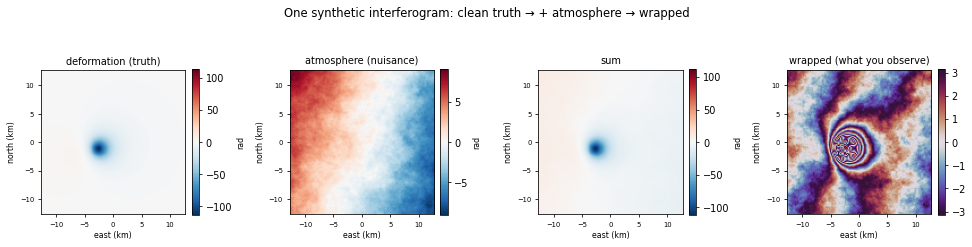

In [8]:
pipeline = InterferogramGenerator(
    deformation=DeformationGenerator(
        grid, {"mogi": SourceGenerator(MogiSource(), DEFAULT_MOGI_PRIOR)}),
    geometry=GeometryGenerator(DEFAULT_S1_GEOMETRY_PRIOR),
    atmosphere=AtmosphereGenerator(
        grid,
        orbital_rms=UniformPrior(2.0, 5.0),
        turbulent_rms=UniformPrior(0.5, 1.5),
        strat_coeff=UniformPrior(-3e-3, 3e-3),
        dem=dem_sampler,   # the real-topography sampler built above — a drop-in `dem=` source
    ),
)
s = pipeline.generate(1, generator=torch.Generator().manual_seed(3))

fig, ax = plt.subplots(1, 4, figsize=(14, 3.4))
imshow(ax[0], field(s.deformation_phase), "deformation (truth)", unit="rad")
imshow(ax[1], field(s.atmosphere),        "atmosphere (nuisance)", unit="rad")
imshow(ax[2], field(s.phase),             "sum", unit="rad")
imshow(ax[3], field(s.wrapped()),         "wrapped (what you observe)", cyclic=True)
fig.suptitle("One synthetic interferogram: clean truth → + atmosphere → wrapped", y=1.04)
plt.tight_layout(); plt.show()

## 7. Priors — and how to write your own

A **prior** is a precise statement of *"what values of this parameter are
plausible?"* When the generator draws a random sample, it draws each parameter
from its prior. The defaults you used above (`DEFAULT_MOGI_PRIOR`, etc.) are just
bundles of priors chosen to span geologically reasonable ranges.

The library ships a whole family of building blocks — uniform on linear, log or
sign-symmetric-log scales, Gaussians and their truncated / log / signed-log
variants, a power law, a von Mises for angles, and discrete / mixture priors — so
you rarely need to write one from scratch. A few you'll reach for most:

- `UniformPrior(low, high)` — every value in a range equally likely.
- `LogUniformPrior(low, high)` — for positive quantities spanning orders of
  magnitude (depth, volume): each *decade* equally likely.
- `SignedLogUniformPrior(low, high)` — same, but with a random sign (e.g. volume
  change can be inflation **or** deflation).
- `MultimodalPrior([...])` — a mixture, for parameters that cluster around
  separate values.

Let's look at what a couple of these actually produce.

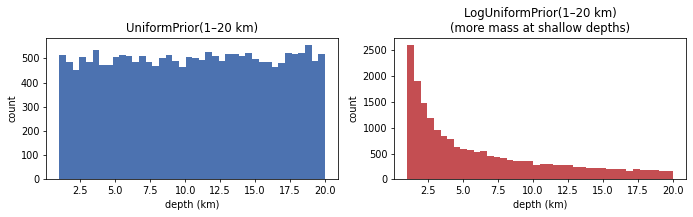

In [9]:
gen0 = torch.Generator().manual_seed(0)
u = UniformPrior(1000.0, 20000.0).sample([20000], generator=gen0)
lg = LogUniformPrior(1000.0, 20000.0).sample([20000], generator=gen0)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].hist(u.numpy() / 1000, bins=40, color="#4C72B0")
ax[0].set_title("UniformPrior(1–20 km)"); ax[0].set_xlabel("depth (km)")
ax[1].hist(lg.numpy() / 1000, bins=40, color="#C44E52")
ax[1].set_title("LogUniformPrior(1–20 km)\n(more mass at shallow depths)")
ax[1].set_xlabel("depth (km)")
for a in ax: a.set_ylabel("count")
plt.tight_layout(); plt.show()

### Writing your own prior

Suppose your field knowledge says: *for this volcano, the magma reservoir sits
around 2 km deep, give or take — deeper or shallower is possible but unlikely.*
We can use a prior to model exactly that.

A prior is any object with a `sample(size, ...)` method that returns a tensor of
that shape. To make a new one, subclass `Prior` and implement `sample`. That's
the whole contract — **anywhere the library accepts a `Prior`, yours will work**.

Here is a **truncated normal** prior (already implemented in the library but given here as an example): a bell curve centred on a preferred value,
clipped to a plausible range. Read the comments; the logic is "keep drawing from a
normal distribution, throw away anything outside the range, until we have enough."

Outside of this example, if a prior is already implemented in the library, it's recommended to use the existing one.

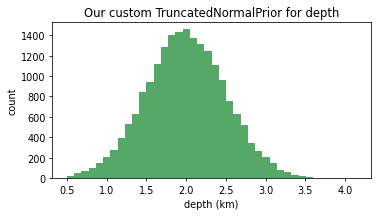

In [10]:
from dataclasses import dataclass

@dataclass(slots=True)
class TruncatedNormalPrior(Prior):
    "A bell curve centred on `mean`, clipped to [low, high]."
    mean: float
    std: float
    low: float
    high: float

    def sample(self, size, generator=None, device=None, dtype=torch.float64):
        out = torch.empty(tuple(size), device=device, dtype=dtype).reshape(-1)
        n, filled = out.numel(), 0
        while filled < n:                                   # rejection sampling
            draw = torch.randn(n, generator=generator, device=device,
                               dtype=dtype) * self.std + self.mean
            ok = draw[(draw >= self.low) & (draw <= self.high)]
            take = min(ok.numel(), n - filled)
            out[filled:filled + take] = ok[:take]
            filled += take
        return out.reshape(tuple(size))

# our belief: reservoir ~2 km deep, sigma 500 m, never outside 0.5–6 km
depth_prior = TruncatedNormalPrior(mean=2000.0, std=500.0, low=500.0, high=6000.0)

samples = depth_prior.sample([20000], generator=torch.Generator().manual_seed(0))
plt.figure(figsize=(5.5, 3.2))
plt.hist(samples.numpy() / 1000, bins=40, color="#55A868")
plt.title("Our custom TruncatedNormalPrior for depth")
plt.xlabel("depth (km)"); plt.ylabel("count")
plt.tight_layout(); plt.show()

The histogram confirms the prior does what we meant: a peak at 2 km, tapering off,
hard cut at the edges. Now we drop it straight into a `MogiPrior` bundle — right
next to a built-in prior for the volume — and generate deformation with it. **No
other code changes.** That's the payoff of the simple `Prior` contract.

drawn depths (km): [1.8, 2.05, 1.72]


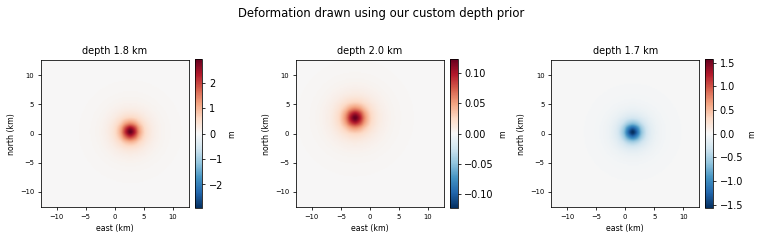

In [11]:
custom_mogi_prior = MogiPrior(
    depth=depth_prior,                              # <-- our prior
    delta_v=SignedLogUniformPrior(1e6, 5e7),        # <-- a built-in, unchanged
)

gen = DeformationGenerator(
    grid, {"mogi": SourceGenerator(MogiSource(), custom_mogi_prior)})
batch = gen.generate(3, generator=torch.Generator().manual_seed(2))

print("drawn depths (km):", (batch.params['mogi']['depth'] / 1000).round(decimals=2).tolist())
fig, ax = plt.subplots(1, 3, figsize=(11, 3.2))
for k in range(3):
    imshow(ax[k], field(batch.displacement.u[k]),
           f"depth {batch.params['mogi']['depth'][k]/1000:.1f} km", unit="m")
fig.suptitle("Deformation drawn using our custom depth prior", y=1.04)
plt.tight_layout(); plt.show()

## 8. Generating a dataset for training

For machine learning you want an object that behaves like a standard PyTorch
`Dataset`: indexable (`dataset[i]`), with a length, and **reproducible** — asking
for sample `i` always returns the same interferogram, whoever asks. `InsarDataset`
wraps any generator to give you exactly that. You can feed it to a
`torch.utils.data.DataLoader` and train as usual.

Here we build a generator that mixes **several source types** (so the model learns
to tell a volcano from an earthquake), then wrap it as a dataset and pull a batch.

10000 reproducible samples
dataset[0].wrapped().shape = (1, 128, 128)


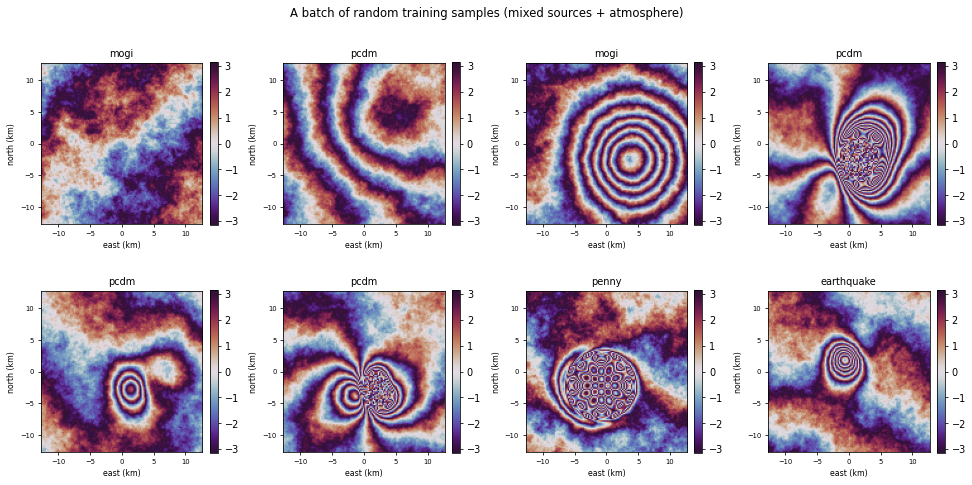

In [12]:
sources = {
    "mogi":       SourceGenerator(MogiSource(), DEFAULT_MOGI_PRIOR),
    "earthquake": SourceGenerator(OkadaSourceSimple(), DEFAULT_EARTHQUAKE_PRIOR,
                                  to_forward=okada_params_from_fault),
    "penny":      SourceGenerator(PennySource(), DEFAULT_PENNY_PRIOR),
    "pcdm":       SourceGenerator(PCDMSource(), DEFAULT_PCDM_PRIOR),
}
pipe = InterferogramGenerator(
    DeformationGenerator(grid, sources),
    GeometryGenerator(DEFAULT_S1_GEOMETRY_PRIOR),
    AtmosphereGenerator(grid, orbital_rms=UniformPrior(2.0, 4.0),
                        turbulent_rms=UniformPrior(0.5, 1.0)),
)

dataset = InsarDataset(pipe, length=10_000)
print(len(dataset), "reproducible samples")
print("dataset[0].wrapped().shape =", tuple(dataset[0].wrapped().shape))

# draw one batch straight from the generator and show the mix of source types
batch = pipe.generate(8, generator=torch.Generator().manual_seed(7))
w = batch.wrapped()
fig, axs = plt.subplots(2, 4, figsize=(14, 7))
for i, a in enumerate(axs.ravel()):
    imshow(a, w[i].cpu().numpy(), batch.deformation.source_type[i], cyclic=True)
fig.suptitle("A batch of random training samples (mixed sources + atmosphere)", y=1.0)
plt.tight_layout(); plt.show()

> **Where do ML labels come from?** The dataset yields *physical* samples (phase,
> parameters, source type). How you turn those into a training target — a class
> label, a segmentation mask, the parameter vector to regress — is up to you, via a
> `transform` you pass to the dataset. Keeping physics and label-encoding separate
> means the same generator serves classification, regression, or denoising.

## 9. The payoff: inversion by gradient descent

Everything so far ran the model **forwards**: parameters → interferogram. Many of
you routinely solve the **inverse** problem with other tools: given a real
interferogram, *what source produced it?* — usually with a Monte-Carlo or
derivative-free optimiser, because computing gradients of a deformation model by
hand is painful.

Because `torchdeform` is written in PyTorch, **the gradient of the interferogram
with respect to the source parameters is available automatically**. That turns
inversion into straightforward gradient descent. This section is a compact demo of
that idea; you can swap in a real interferogram wherever we use synthetic "data".

**The setup.** We pretend we observed an interferogram from a Mogi source at
3.5 km depth with a volume change of 8×10⁶ m³. We then *forget* those numbers and
try to recover them, starting from a deliberately wrong guess.

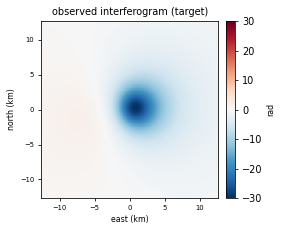

In [13]:
# --- 1. the "observed" data (in practice: load a real interferogram here) ---
true_depth, true_dv = torch.tensor([3500.0]), torch.tensor([8e6])
with torch.no_grad():
    d = mogi(x_obs, y_obs, source_x=z, source_y=z, depth=true_depth, delta_v=true_dv)
    observed = to_phase(d.to_los(los))

imshow(plt.subplots(figsize=(4, 3.4))[1], field(observed),
       "observed interferogram (target)", unit="rad")
plt.tight_layout(); plt.show()

**The unknowns.** We optimise depth and volume. We optimise them in *log space*
(`log_depth`, `log_dv`) so they stay positive and so the very different scales
(thousands of metres vs millions of cubic metres) don't trip up the optimiser —
a standard trick. `requires_grad=True` is the one line that tells PyTorch "track
how the loss depends on these, so I can get gradients."

**The loop.** At each step we (1) run the model forward with the current guess,
(2) measure the mismatch to the data (mean squared phase error), (3) call
`loss.backward()` to get the gradients automatically, and (4) nudge the parameters
downhill. That's the entire inversion.

In [14]:
# --- 2. unknowns: start from a wrong guess (1.5 km, 2e6 m^3), optimise in log-space ---
log_depth = torch.tensor([math.log(1500.0)], requires_grad=True)
log_dv    = torch.tensor([math.log(2e6)],   requires_grad=True)
opt = torch.optim.Adam([log_depth, log_dv], lr=0.05)

history = []
for step in range(400):
    opt.zero_grad()
    depth, dv = log_depth.exp(), log_dv.exp()
    pred = to_phase(mogi(x_obs, y_obs, source_x=z, source_y=z,
                         depth=depth, delta_v=dv).to_los(los))
    loss = ((pred - observed) ** 2).mean()      # data misfit
    loss.backward()                              # <-- gradients, for free
    opt.step()
    history.append((loss.item(), depth.item(), dv.item()))

print(f"recovered depth = {log_depth.exp().item():7.1f} m   (true 3500)")
print(f"recovered volume = {log_dv.exp().item():.3e} m³  (true 8.000e+06)")

recovered depth =  3500.0 m   (true 3500)
recovered volume = 8.000e+06 m³  (true 8.000e+06)


Both parameters are recovered essentially exactly. Let's watch the optimiser get
there — the misfit dropping, and each parameter converging on its true value.

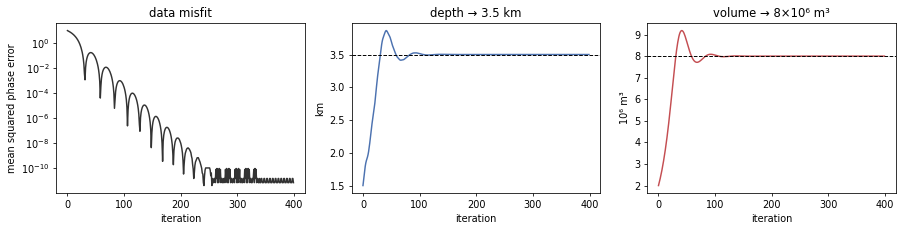

In [15]:
loss_h = [h[0] for h in history]
dep_h  = [h[1] / 1000 for h in history]
dv_h   = [h[2] / 1e6 for h in history]

fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
ax[0].semilogy(loss_h, color="#333333"); ax[0].set_title("data misfit")
ax[0].set_xlabel("iteration"); ax[0].set_ylabel("mean squared phase error")
ax[1].plot(dep_h, color="#4C72B0"); ax[1].axhline(3.5, ls="--", color="k", lw=1)
ax[1].set_title("depth → 3.5 km"); ax[1].set_xlabel("iteration"); ax[1].set_ylabel("km")
ax[2].plot(dv_h, color="#C44E52"); ax[2].axhline(8.0, ls="--", color="k", lw=1)
ax[2].set_title("volume → 8×10⁶ m³"); ax[2].set_xlabel("iteration"); ax[2].set_ylabel("10⁶ m³")
plt.tight_layout(); plt.show()

Finally, the fit itself: observed, recovered, and their (tiny) residual.

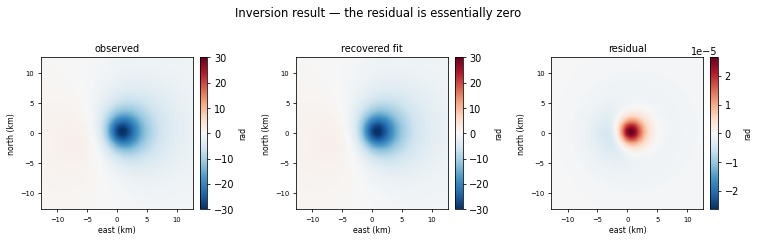

In [16]:
with torch.no_grad():
    fit = to_phase(mogi(x_obs, y_obs, source_x=z, source_y=z,
                        depth=log_depth.exp(), delta_v=log_dv.exp()).to_los(los))
fig, ax = plt.subplots(1, 3, figsize=(11, 3.2))
imshow(ax[0], field(observed),        "observed", unit="rad")
imshow(ax[1], field(fit),             "recovered fit", unit="rad")
imshow(ax[2], field(observed - fit),  "residual", unit="rad")
fig.suptitle("Inversion result — the residual is essentially zero", y=1.04)
plt.tight_layout(); plt.show()

### Two surprising features about this

Readers coming from classical inversion tools might notice two features of the
cell above, both worth addressing head-on:

1. *Speed* — Classical InSAR inversion often
   runs for **hours**, so a demo that finishes in seconds invites suspicion.
2. *Gradient-descend on **all** parameters at once* — With
   hand-coded or finite-difference gradients that isn't possible, with
   autodiff it isn't a problem.

Let's just measure the first and demonstrate the second.

In [ ]:
import time

# (a) HOW FAST? re-run the whole inversion as a timed function.
def invert_mogi(n_steps=400):
    lg_d = torch.tensor([math.log(1500.0)], requires_grad=True)
    lg_v = torch.tensor([math.log(2e6)],    requires_grad=True)
    opt  = torch.optim.Adam([lg_d, lg_v], lr=0.05)
    for _ in range(n_steps):
        opt.zero_grad()
        pred = to_phase(mogi(x_obs, y_obs, source_x=z, source_y=z,
                             depth=lg_d.exp(), delta_v=lg_v.exp()).to_los(los))
        ((pred - observed) ** 2).mean().backward()
        opt.step()
    return lg_d.exp().item(), lg_v.exp().item()

invert_mogi(1)                                          # warm-up (skip first-call overhead)
t0 = time.perf_counter(); invert_mogi(); dt = time.perf_counter() - t0
print(f"full 400-step inversion: {dt*1e3:6.0f} ms  ({dt/400*1e3:.2f} ms/iter), CPU only\n")

# (b) ALL PARAMETERS AT ONCE: recover depth, volume AND horizontal position.
tx, ty = torch.tensor([1200.0]), torch.tensor([-800.0])          # true (offset) location
with torch.no_grad():
    obs4 = to_phase(mogi(x_obs, y_obs, source_x=tx, source_y=ty,
                         depth=torch.tensor([3500.0]),
                         delta_v=torch.tensor([8e6])).to_los(los))

lg_d = torch.tensor([math.log(1500.0)], requires_grad=True)
lg_v = torch.tensor([math.log(2e6)],    requires_grad=True)
sx   = torch.tensor([0.0], requires_grad=True)                   # start at the centre
sy   = torch.tensor([0.0], requires_grad=True)
# depth/volume live in log-space; position lives in metres, so give each group its
# own step size — the one extra bit of care that many-parameter inversion needs.
opt = torch.optim.Adam([{"params": [lg_d, lg_v], "lr": 0.05},
                        {"params": [sx, sy],     "lr": 50.0}])
for _ in range(400):
    opt.zero_grad()
    pred = to_phase(mogi(x_obs, y_obs, source_x=sx, source_y=sy,
                         depth=lg_d.exp(), delta_v=lg_v.exp()).to_los(los))
    ((pred - obs4) ** 2).mean().backward()               # <-- ONE backward → all 4 gradients
    opt.step()

print("4-parameter inversion (a single backward pass gives every gradient):")
print(f"  depth  = {lg_d.exp().item():7.1f} m   (true 3500)")
print(f"  volume = {lg_v.exp().item():.3e} m³  (true 8.000e+06)")
print(f"  east   = {sx.item():7.1f} m   (true 1200)")
print(f"  north  = {sy.item():7.1f} m   (true -800)")

**Why adding parameters is essentially free.** The surprising line is
that recovering *four* parameters cost no more per step than recovering two — and
that a single `loss.backward()` produced the gradient for **all** of them at once.
That is the defining property of **reverse-mode autodiff** (the *adjoint* method):
one backward pass costs about the same as one forward pass and returns
∂loss/∂θ for *every* parameter θ simultaneously, **regardless of how many there
are**. Going from 4 unknowns to 40 barely changes the runtime.

Contrast that with the two families of tools most inversions use today, and it's
clear why seconds-not-hours is possible:

- **Finite differences** would need one extra forward evaluation *per parameter*
  just to assemble a single gradient. Autodiff gets the whole gradient in one pass
  — which is exactly why "all parameters at once" is the *natural* mode here, not a
  heroic one.
- **Derivative-free / Monte-Carlo optimisers** (MCMC, Neighbourhood Algorithm,
  simulated annealing) have no gradient at all, so they explore by trial and error,
  needing 10⁴–10⁶ forward runs to converge or map a posterior. Gradient descent
  replaces that with a few hundred *informed* steps.

The **only** extra care with many parameters is *scaling*: depth and volume live
in log-space while position is in metres, so we gave each its own learning rate
above. That's numerical conditioning, not a limit on how many parameters you can
invert — swap in an Okada fault and optimise strike/dip/rake/slip the same way.

### Where to go from here

- **Real data.** Replace `observed` with a real (unwrapped) interferogram and the
  same loop inverts it. For *wrapped* data, compare in the wrapped domain using
  `torchdeform`'s `wrapped_phase_loss` so 2π jumps don't wreck the misfit.
- **More parameters.** Add `source_x`, `source_y`, or switch to an Okada fault and
  optimise strike/dip/slip — the recipe is identical, just more unknowns.
- **Harder sources.** The Okada model has exact analytic gradients available
  (`analytic_grad=True`) for robust inversion even on singular fault geometries —
  see the tutorial and the `okada.py` docstrings.
- **Hybrid workflows.** Because the forward model is differentiable, you can train
  a network to *propose* a source and then *refine* it with a few gradient steps —
  the best of both worlds.

That's the whole story: a physical forward model you can run at scale to make
data, and differentiate to invert data. Happy synthesising!